# 6 - AM SDR Demod (IQ/Magnitude)

SDR-Capture/Replay nach Labor-3-Prinzip, danach IQ-Demodulation mit lokalem LO und Magnitude.

In [20]:
import json
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True

In [21]:
# Parameter
CENTER_FREQ_HZ = 434.0e6
SAMPLE_RATE_HZ = 2.048e6
GAIN_DB = 40.0
TOTAL_SAMPLES = 262_144*4

REPLAY = True
REPLAY_FILE = Path('recordings') / 'am_sdr_replay.json'

# Fallback-IF für synthetisches Testsignal (nur wenn kein RTL-SDR verfügbar)
f_if_fallback_hz = 0.0

# Globale Peak-/LO-Konfiguration für IF-Schätzung
SEARCH_F_MIN_HZ = 1_000.0
SEARCH_F_MAX_HZ = 150_000.0   # Schutzfenster: nur in diesem IF-Bereich suchen
DC_GUARD_MIN_HZ = 500.0
F_LO_OFFSET_HZ = 500.0        # kleiner Offset, damit Low-IF sichtbar bleibt

# Optionale FFT-Fensterung gegen Leakage
USE_FFT_WINDOW = True
FFT_WINDOW_KIND = 'hann'  # 'hann' | 'hamming' | 'rect'

def setup_rtlsdr_driver_path() -> None:
    driver_dir = None
    for p in [Path.cwd()] + list(Path.cwd().parents):
        cand = p / 'rtl-sdr-driver'
        if cand.exists() and (cand / 'librtlsdr.dll').exists():
            driver_dir = cand
            break
    if driver_dir is not None:
        os.environ['PATH'] = str(driver_dir) + os.pathsep + os.environ.get('PATH', '')
        try:
            os.add_dll_directory(str(driver_dir))
        except Exception:
            pass
        print('RTL-SDR Treiber gefunden:', driver_dir)

def capture_iq_or_fallback(center_hz: float, fs_hz: float, gain_db: float, total_samples: int) -> np.ndarray:
    setup_rtlsdr_driver_path()
    try:
        from rtlsdr import RtlSdr
        sdr = RtlSdr()
        sdr.sample_rate = fs_hz
        sdr.center_freq = center_hz
        sdr.gain = gain_db
        iq = sdr.read_samples(total_samples)
        sdr.close()
        return np.asarray(iq, dtype=np.complex64)
    except Exception as ex:
        print('RTL-SDR nicht verfügbar, nutze synthetischen Fallback:', ex)
        t = np.arange(total_samples, dtype=np.float64) / fs_hz
        f_car = f_if_fallback_hz
        f_mod = 1_000.0
        m = 0.6
        env = 1 + m * np.cos(2*np.pi*f_mod*t)
        x = env * np.exp(1j*2*np.pi*f_car*t)
        noise = 0.02*(np.random.randn(total_samples)+1j*np.random.randn(total_samples))
        return (x + noise).astype(np.complex64)

def save_replay_iq(path: Path, iq: np.ndarray, fs_hz: float, center_hz: float, gain_db: float) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    data = {
        'meta': {'type': 'am_sdr_iq', 'version': 1},
        'sample_rate_hz': fs_hz,
        'center_freq_hz': center_hz,
        'gain_db': gain_db,
        'iq_re': np.real(iq).astype(float).tolist(),
        'iq_im': np.imag(iq).astype(float).tolist(),
    }
    path.write_text(json.dumps(data, indent=2), encoding='utf-8')

def load_replay_iq(path: Path) -> np.ndarray:
    data = json.loads(path.read_text(encoding='utf-8'))
    re = np.asarray(data['iq_re'], dtype=np.float32)
    im = np.asarray(data['iq_im'], dtype=np.float32)
    return (re + 1j*im).astype(np.complex64)

In [22]:
# Capture oder Replay
if REPLAY and REPLAY_FILE.exists():
    iq = load_replay_iq(REPLAY_FILE)
    print('Replay-IQ geladen:', REPLAY_FILE)
else:
    iq = capture_iq_or_fallback(CENTER_FREQ_HZ, SAMPLE_RATE_HZ, GAIN_DB, TOTAL_SAMPLES)
    save_replay_iq(REPLAY_FILE, iq, SAMPLE_RATE_HZ, CENTER_FREQ_HZ, GAIN_DB)
    print('Replay-IQ gespeichert:', REPLAY_FILE)

if iq.size < TOTAL_SAMPLES:
    raise RuntimeError(f'Zu wenige Samples: {iq.size} < {TOTAL_SAMPLES}')
iq = iq[:TOTAL_SAMPLES].astype(np.complex64)
fs = float(SAMPLE_RATE_HZ)
t = np.arange(len(iq)) / fs

Replay-IQ geladen: recordings\am_sdr_replay.json


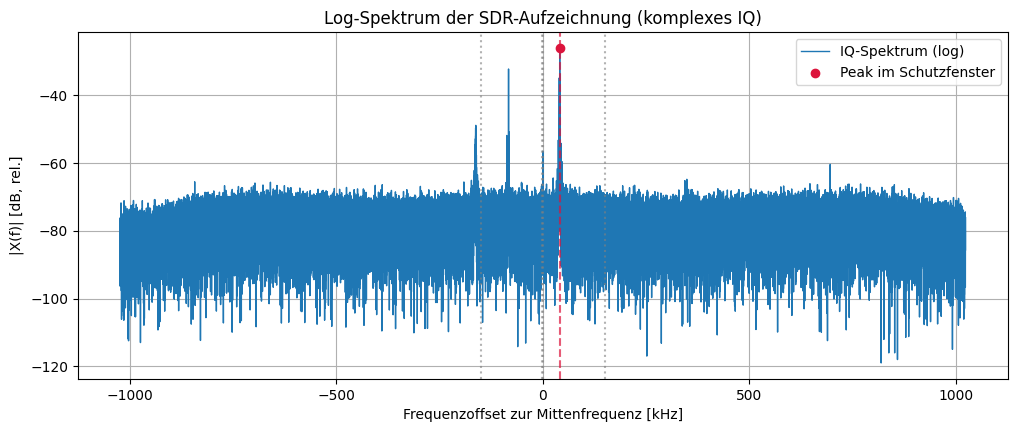

Peak-Frequenz (IF-Schätzung): 41000.0 Hz
Schutzfenster: 1000.0 .. 150000.0 Hz
Gewähltes f_lo: 40500.0 Hz (Offset 500.0 Hz)


In [23]:
# Zweiseitiges Log-Spektrum direkt nach dem Einlesen (komplexes IQ) + IF-Peak-Schätzung
N_fft_spec = 16384*4
x_spec = iq[:N_fft_spec]
if USE_FFT_WINDOW:
    if FFT_WINDOW_KIND == 'hann':
        w_spec = np.hanning(N_fft_spec)
    elif FFT_WINDOW_KIND == 'hamming':
        w_spec = np.hamming(N_fft_spec)
    else:
        w_spec = np.ones(N_fft_spec)
else:
    w_spec = np.ones(N_fft_spec)

cg_spec = np.mean(w_spec)
X_spec = np.fft.fftshift(np.fft.fft(x_spec * w_spec, n=N_fft_spec))
f_spec = np.fft.fftshift(np.fft.fftfreq(N_fft_spec, d=1/fs))
A_spec = np.abs(X_spec) / (N_fft_spec * max(cg_spec, 1e-12))
S_db = 20*np.log10(np.maximum(A_spec, 1e-12))

# Peak-Suche mit symmetrischem Schutzfenster um 0 Hz (Störer außerhalb ignorieren)
dc_guard_hz = max(DC_GUARD_MIN_HZ, fs / N_fft_spec)

# Symmetrisch: SEARCH_F_MIN_HZ <= |f| <= SEARCH_F_MAX_HZ
peak_mask = (
    (np.abs(f_spec) >= max(dc_guard_hz, SEARCH_F_MIN_HZ))
    & (np.abs(f_spec) <= SEARCH_F_MAX_HZ)
)

if not np.any(peak_mask):
    raise RuntimeError('Peak-Suchfenster ist leer. Prüfe SEARCH_F_MIN_HZ/SEARCH_F_MAX_HZ.')

idx_peak = np.argmax(A_spec[peak_mask])
peak_f_hz = float(f_spec[peak_mask][idx_peak])
peak_a = float(A_spec[peak_mask][idx_peak])

# LO aus Peak schätzen (kleiner Offset, damit Low-IF sichtbar bleibt)
f_if_est_hz = peak_f_hz
f_lo = f_if_est_hz - F_LO_OFFSET_HZ

plt.figure(figsize=(12, 4.5))
plt.plot(f_spec/1e3, S_db, lw=1.0, label='IQ-Spektrum (log)')
plt.scatter([peak_f_hz/1e3], [20*np.log10(max(peak_a,1e-12))], color='crimson', zorder=4, label='Peak im Schutzfenster')
plt.axvline(peak_f_hz/1e3, color='crimson', ls='--', alpha=0.7)
plt.axvline( SEARCH_F_MIN_HZ/1e3, color='gray', ls=':', alpha=0.6)
plt.axvline( SEARCH_F_MAX_HZ/1e3, color='gray', ls=':', alpha=0.6)
plt.axvline(-SEARCH_F_MIN_HZ/1e3, color='gray', ls=':', alpha=0.6)
plt.axvline(-SEARCH_F_MAX_HZ/1e3, color='gray', ls=':', alpha=0.6)
plt.title('Log-Spektrum der SDR-Aufzeichnung (komplexes IQ)')
plt.xlabel('Frequenzoffset zur Mittenfrequenz [kHz]')
plt.ylabel('|X(f)| [dB, rel.]')
plt.legend()
plt.show()

print(f'Peak-Frequenz (IF-Schätzung): {peak_f_hz:.1f} Hz')
print(f'Schutzfenster: {SEARCH_F_MIN_HZ:.1f} .. {SEARCH_F_MAX_HZ:.1f} Hz')
print(f'Gewähltes f_lo: {f_lo:.1f} Hz (Offset {F_LO_OFFSET_HZ:.1f} Hz)')

In [24]:
# IQ-Demodulation mit lokalem LO (aus Spektrum geschätzt)

# Komplexe Mischung auf Low-IF / Basisband
z = iq * np.exp(-1j * 2*np.pi * f_lo * t)

# I- und Q-Anteil
i = np.real(z)
q = np.imag(z)

# Einfacher Tiefpass über gleitenden Mittelwert
f_lp = 2_000.0
N_win = max(3, int(round(fs / max(1.0, f_lp))))
if N_win % 2 == 0:
    N_win += 1

kernel = np.ones(N_win) / N_win

I = np.convolve(i, kernel, mode='same')
Q = np.convolve(q, kernel, mode='same')

# Hüllkurvendetektion über Betrag
u_demod = np.sqrt(I**2 + Q**2)

# DC-Anteil entfernen
u_demod = u_demod - np.mean(u_demod)

print(f'f_lo = {f_lo:.1f} Hz, N_win = {N_win}')

f_lo = 40500.0 Hz, N_win = 1025


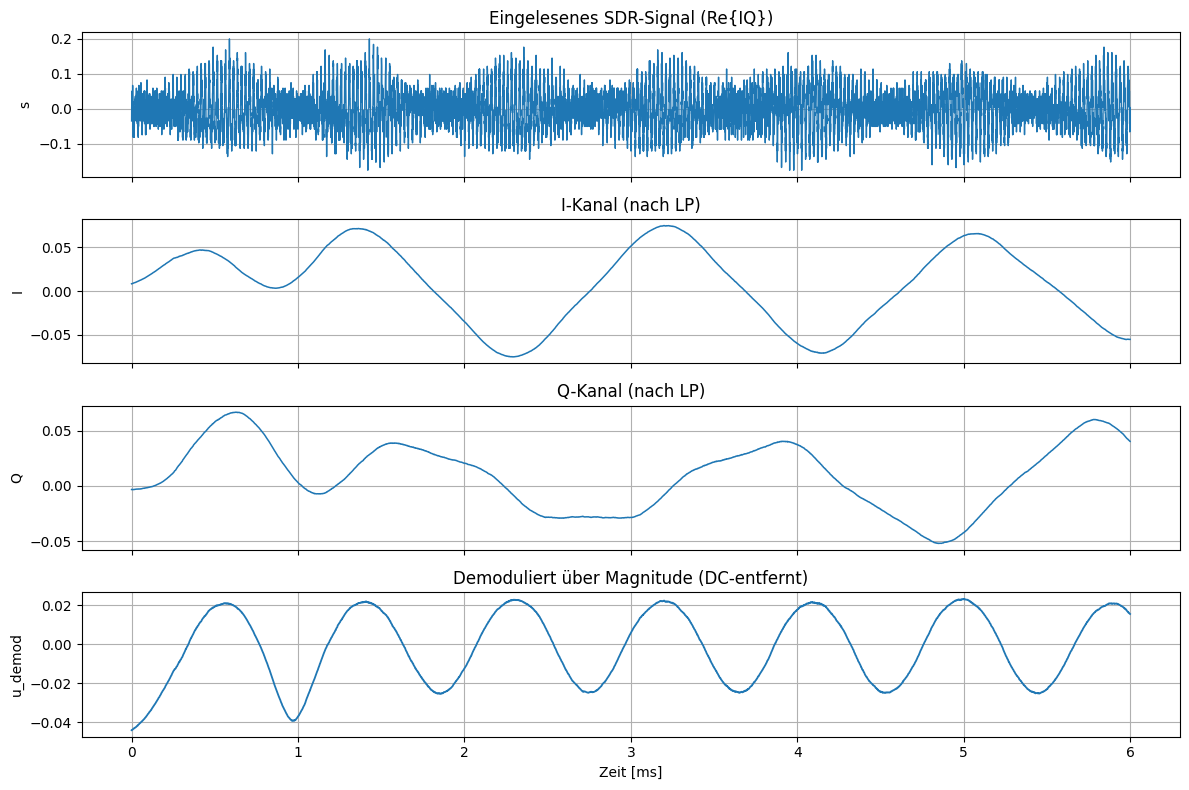

In [25]:
# Plots: Signal, I/Q, Demod
s_real = np.real(iq).astype(np.float64)
t_plot_ms = 6.0
n_plot = min(len(iq), int(t_plot_ms*1e-3*fs))

fig, ax = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
ax[0].plot(t[:n_plot]*1e3, s_real[:n_plot], lw=1.0)
ax[0].set_title('Eingelesenes SDR-Signal (Re{IQ})')
ax[0].set_ylabel('s')

ax[1].plot(t[:n_plot]*1e3, I[:n_plot], lw=1.1)
ax[1].set_title('I-Kanal (nach LP)')
ax[1].set_ylabel('I')

ax[2].plot(t[:n_plot]*1e3, Q[:n_plot], lw=1.1)
ax[2].set_title('Q-Kanal (nach LP)')
ax[2].set_ylabel('Q')

ax[3].plot(t[:n_plot]*1e3, u_demod[:n_plot], lw=1.3)
ax[3].set_title('Demoduliert über Magnitude (DC-entfernt)')
ax[3].set_ylabel('u_demod')
ax[3].set_xlabel('Zeit [ms]')
plt.tight_layout(); plt.show()

In [26]:
# (Info) Log-Spektrum + Peak-Schätzung wurde bereits direkt nach dem Einlesen gezeigt.
pass

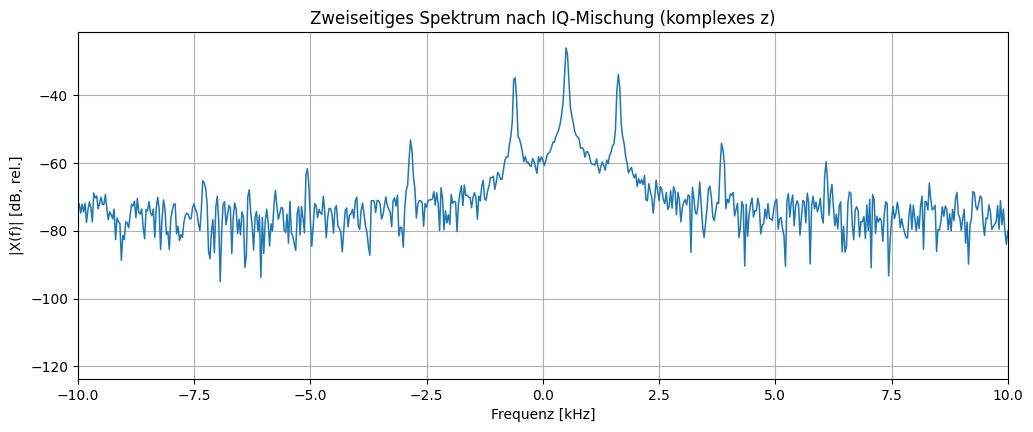

In [27]:
# Zweiseitiges Spektrum nach Mischung (Low-IF sichtbar) über komplexes Basisbandsignal z
N_fft = 16384*4
x = np.zeros(N_fft, dtype=np.complex128)
n_copy = min(len(z), N_fft)
x[:n_copy] = z[:n_copy]
if USE_FFT_WINDOW:
    if FFT_WINDOW_KIND == 'hann':
        w = np.hanning(N_fft)
    elif FFT_WINDOW_KIND == 'hamming':
        w = np.hamming(N_fft)
    else:
        w = np.ones(N_fft)
else:
    w = np.ones(N_fft)

cg = np.mean(w)
X = np.fft.fftshift(np.fft.fft(x * w, n=N_fft))
f = np.fft.fftshift(np.fft.fftfreq(N_fft, d=1/fs))
A = np.abs(X) / (N_fft * max(cg, 1e-12))
A_db = 20*np.log10(np.maximum(A, 1e-12))

plt.figure(figsize=(12, 4.5))
plt.plot(f/1e3, A_db, lw=1.1)
plt.xlim(-10, 10)
plt.title('Zweiseitiges Spektrum nach IQ-Mischung (komplexes z)')
plt.xlabel('Frequenz [kHz]')
plt.ylabel('|X(f)| [dB, rel.]')
plt.show()

In [28]:
# Audio (48 kS/s, zyklisch)
fs_audio = 48_000
duration_s = 4.0
t_src = np.arange(len(u_demod)) / fs
n_dst = int(round(len(u_demod) * fs_audio / fs))
t_dst = np.arange(n_dst) / fs_audio
u_audio_base = np.interp(t_dst, t_src, u_demod)
n_target = int(duration_s * fs_audio)
u_audio = np.tile(u_audio_base, int(np.ceil(n_target / len(u_audio_base))))[:n_target]
u_audio = u_audio / max(1e-12, np.max(np.abs(u_audio)))
display(Audio(u_audio, rate=fs_audio))